# Phân tích chuyên sâu về chỉ số Insulin - Pima Indians Diabetes (Test 02)

Notebook này phân tích biến `insulin`. Khác với Test 01 (loại bỏ giá trị 0 thành `NaN`), ở **Test 02** này chúng ta sẽ **điền khuyết (impute) các giá trị 0 bằng giá trị Trung vị (Median)** của những người có chỉ số Insulin hợp lệ.

Trọng tâm:
- Thống kê mô tả về biến Insulin
- Điền khuyết (Impute) các giá trị 0 bằng Median
- Phân bố của Insulin sau khi điền khuyết
- Quan sát sự khác biệt so với Test 01

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
column_names = [
    "pregnancies",
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "insulin",
    "bmi",
    "diabetes_pedigree_function",
    "age",
    "outcome",
]

In [3]:
# Tự động tìm đường dẫn gốc của project
current = Path().resolve()
while not (current / "Lab_03").exists():
    current = current.parent

data_path = current / "Lab_03" / "data" / "pima-indians-diabetes.csv"

df = pd.read_csv(data_path, header=None, names=column_names)
df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Dữ liệu gốc (Bao gồm các giá trị 0)

Trong bộ dữ liệu gốc, insulin có chứa các giá trị 0 (đây thực chất là missing value).

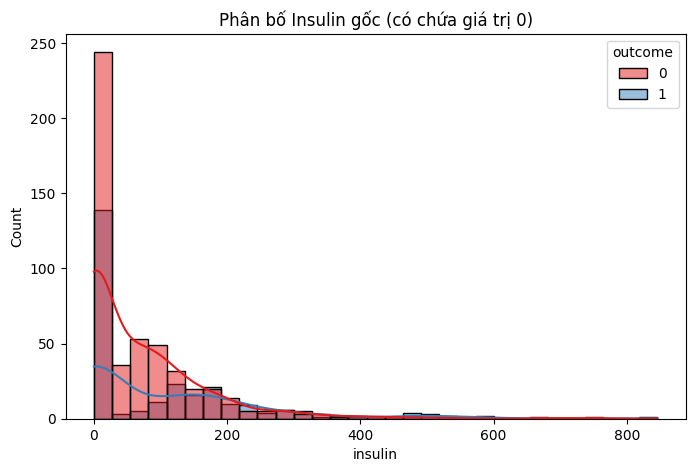

In [4]:
fig_raw, ax_raw = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df, 
    x="insulin", 
    hue="outcome", 
    kde=True, 
    ax=ax_raw,
    palette="Set1"
)
ax_raw.set_title("Phân bố Insulin gốc (có chứa giá trị 0)")
plt.show()

In [5]:
zero_count = (df['insulin'] == 0).sum()
zero_rate = (zero_count / len(df)) * 100

print(f"Số lượng người có mức Insulin bằng 0: {zero_count} ({zero_rate:.2f}% tập dữ liệu)")

Số lượng người có mức Insulin bằng 0: 374 (48.70% tập dữ liệu)


## 2. Điền khuyết dữ liệu bằng trung Vị (Median Imputation)

Thay vì vứt bỏ các giá trị 0 (biến thành `NaN` như Test 01), ta sẽ tính Median của những người có Insulin > 0, sau đó dùng con số đó lấp vào tất cả những chỗ bị 0.

In [6]:
df_imputed = df.copy()

# Tính trung vị của các giá trị Insulin hợp lệ (khác 0)
median_insulin = df_imputed[df_imputed['insulin'] != 0]['insulin'].median()
print(f"Giá trị trung vị của Insulin (chỉ tính các ca > 0): {median_insulin}")

# Thay thế số 0 bằng giá trị trung vị vừa tìm được
df_imputed['insulin'] = df_imputed['insulin'].replace(0, median_insulin)

# Thống kê mô tả insulin sau khi điền khuyết
df_imputed[['insulin']].describe().T

Giá trị trung vị của Insulin (chỉ tính các ca > 0): 125.0


,count,mean,std,min,25%,50%,75%,max
insulin,768.0,140.671875,86.38306,14.0,121.5,125.0,127.25,846.0


### Nhận xét sự khác biệt so với Test 01:
- Số lượng mẫu (count) lúc này sẽ là 768 (toàn bộ tập dữ liệu), thay vì 394 như Test 01.
- Các giá trị trung bình (mean), độ lệch chuẩn (std) và các tứ phân vị sẽ bị biến đổi mạnh do có tới 374 giá trị (gần 50% dữ liệu) bị ép về cùng 1 số (median).

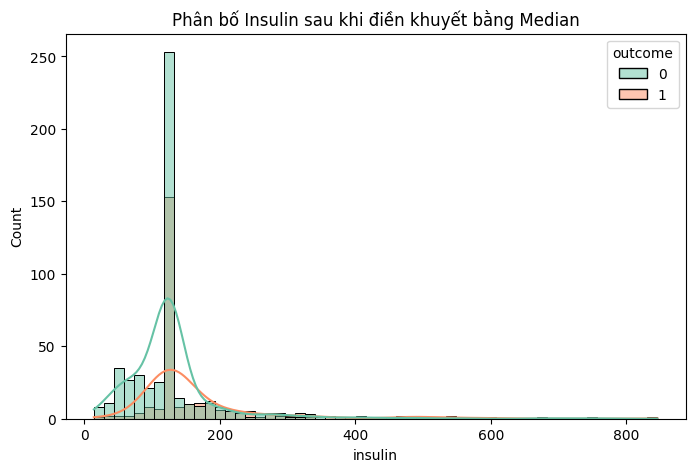

In [7]:
fig_clean, ax_clean = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df_imputed, 
    x="insulin", 
    hue="outcome", 
    kde=True, 
    ax=ax_clean,
    palette="Set2"
)
ax_clean.set_title("Phân bố Insulin sau khi điền khuyết bằng Median")
plt.show()

**Quan sát biểu đồ phân bố:** Thấy một **cột rất cao (đỉnh nhọn)** trồi lên ngay tại vị trí Median (125.0). Điều này làm thay đổi hoàn toàn hình dáng phân bố tự nhiên của dữ liệu.

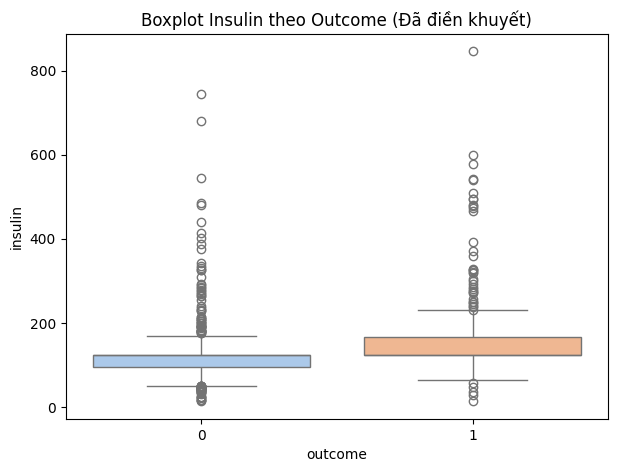

In [8]:
fifig_box, ax_box = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=df_imputed,
    x="outcome",
    y="insulin",
    hue="outcome",        
    legend=False,         
    ax=ax_box,
    palette="pastel"
)
ax_box.set_title("Boxplot Insulin theo Outcome (Đã điền khuyết)")
plt.show()


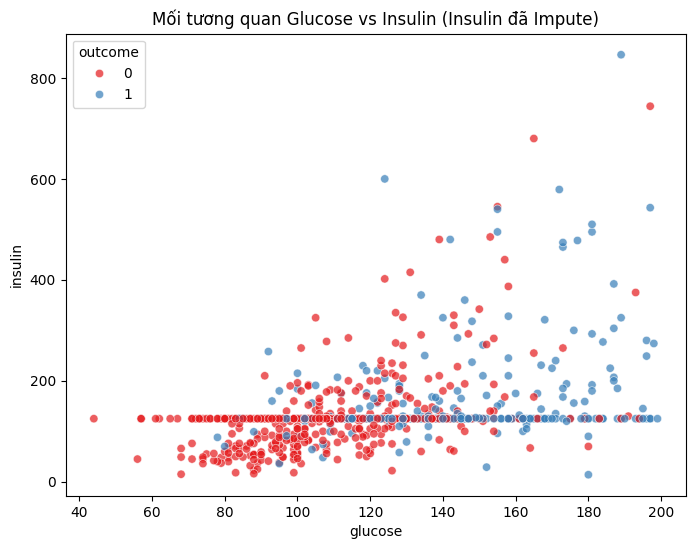

In [9]:
# Mối tương quan giữa Glucose và Insulin sau khi điền khuyết
fig_scatter, ax_scatter = plt.subplots(figsize=(8, 6))

plot_df = df_imputed.copy()
plot_df['glucose'] = plot_df['glucose'].replace(0, float('nan'))

sns.scatterplot(
    data=plot_df,
    x="glucose",
    y="insulin",
    hue="outcome",
    alpha=0.7,
    ax=ax_scatter,
    palette="Set1"
)
ax_scatter.set_title("Mối tương quan Glucose vs Insulin (Insulin đã Impute)")
plt.show()

**Quan sát Scatterplot:** Sẽ thấy một đường thẳng nằm ngang tập trung rất đông các điểm tại trục `y = 125.0` (giá trị Median). Việc điền khuyết quá nhiều (gần 50%) bằng 1 giá trị duy nhất sẽ làm méo mó các mối quan hệ tương quan tự nhiên giữa các biến.

## Chuẩn bị dữ liệu
Chúng ta sẽ tách biến mục tiêu (`outcome`) ra khỏi các đặc trưng (features). Sau đó, chia dữ liệu thành 3 tập: **Train (Huấn luyện) 60%**, **Validation (Xác thực) 20%**, và **Test (Kiểm tra) 20%**.


In [10]:
from sklearn.model_selection import train_test_split

# Tách đặc trưng (X) và nhãn (y)
X = df_imputed.drop('outcome', axis=1)
y = df_imputed['outcome']

# Lần 1: Tách 20% làm tập Test, 80% còn lại làm tập tạm (Train + Val)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lần 2: Tách 25% của tập tạm làm Validation (tương đương 20% của tổng dữ liệu gốc)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Kích thước tập Train (60%): {X_train.shape}")
print(f"Kích thước tập Validation (20%): {X_val.shape}")
print(f"Kích thước tập Test (20%): {X_test.shape}")


Kích thước tập Train (60%): (460, 8)
Kích thước tập Validation (20%): (154, 8)
Kích thước tập Test (20%): (154, 8)


## 6. Huấn luyện và tinh chỉnh tham số
Sử dụng tập **Train** để huấn luyện các mô hình `RandomForestClassifier` với nhiều giá trị `max_depth` (độ sâu tối đa của cây) khác nhau. Sau đó, dùng tập **Validation** để đánh giá và chọn ra tham số tốt nhất.


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Thử nghiệm các giá trị max_depth khác nhau
depths = [3, 5, 7, 10, None]
best_depth = depths[0]
best_acc = 0

print("Kết quả đánh giá trên tập Validation:")
for depth in depths:
    # Khởi tạo và huấn luyện mô hình
    rf = RandomForestClassifier(max_depth=depth, random_state=42)
    rf.fit(X_train, y_train)
    
    # Dự đoán và tính độ chính xác trên tập Validation
    y_val_pred = rf.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    print(f" - max_depth={depth}: Accuracy = {acc:.4f}")
    
    # Lưu lại tham số tốt nhất
    if acc > best_acc:
        best_acc = acc
        best_depth = depth

print(f"\n=> Tham số tốt nhất được chọn: max_depth={best_depth} (Accuracy: {best_acc:.4f})")


Kết quả đánh giá trên tập Validation:
 - max_depth=3: Accuracy = 0.7532
 - max_depth=5: Accuracy = 0.7532
 - max_depth=7: Accuracy = 0.7532
 - max_depth=10: Accuracy = 0.7597
 - max_depth=None: Accuracy = 0.7597

=> Tham số tốt nhất được chọn: max_depth=10 (Accuracy: 0.7597)


## Huấn luyện mô hình cuối cùng
Sau khi tìm được `max_depth` tốt nhất, ta sẽ **gộp tập Train và Validation** để có nhiều dữ liệu hơn (80%), sau đó huấn luyện mô hình cuối cùng. Bước cuối là đánh giá mô hình này trên tập **Test** đã được giữ lại từ đầu.


BÁO CÁO PHÂN LOẠI TRÊN TẬP TEST:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



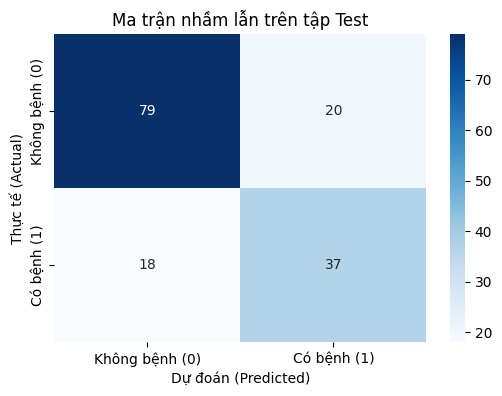

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

# Gộp tập Train và Validation (chính là tập X_temp, y_temp ban đầu)
final_model = RandomForestClassifier(max_depth=best_depth, random_state=42)
final_model.fit(X_temp, y_temp)

# Dự đoán trên tập Test
y_test_pred = final_model.predict(X_test)

# In báo cáo phân loại
print("BÁO CÁO PHÂN LOẠI TRÊN TẬP TEST:")
print(classification_report(y_test, y_test_pred))

# Vẽ ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Không bệnh (0)', 'Có bệnh (1)'], 
            yticklabels=['Không bệnh (0)', 'Có bệnh (1)'])
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Ma trận nhầm lẫn trên tập Test')
plt.show()


## Phân tích kết quả đánh giá
Từ báo cáo phân loại và ma trận nhầm lẫn, chúng ta có thể đánh giá được chất lượng của mô hình Random Forest đối với dữ liệu Insulin điền khuyết bằng trung vị.

Việc điền một lượng lớn Insulin bằng 1 giá trị duy nhất (gần 50%) thường làm giảm đáng kể khả năng phân biệt bệnh nhân của mô hình. Phương pháp thay thế bằng trung vị tạo ra sự thiên lệch (bias) rất lớn đối với những cá nhân mắc bệnh, từ đó có thể làm mô hình ưu tiên dự đoán những trường hợp 'Không bệnh' và gây ra sai số cao (tỉ lệ Recall cho nhóm có bệnh sẽ thấp).

**Kết luận:** Phương pháp điền khuyết bằng trung vị (Median Imputation) là một chiến lược không tốt đối với biến `Insulin`, làm mất các mối quan hệ quan trọng. Vì vậy, ta cần sử dụng các thuật toán máy học như KNN hoặc MICE để thay thế giá trị hợp lý hơn.
